In [6]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from tqdm.notebook import tqdm
from kloppy import statsbomb
from kloppy.domain.models.event import EventType, PassResult
from statsbombpy import sb

In [7]:
# UEFA Women's EURO 2022 — открытые данные StatsBomb 360 + events
matches_df = sb.matches(competition_id=53, season_id=106)
match_ids = matches_df['match_id'].tolist()
print(f"Матчей: {len(match_ids)}")

Матчей: 31


In [8]:
matches_df.head(5)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3835331,2022-07-13,18:00:00.000,Europe - UEFA Women's Euro,2022,Sweden Women's,Switzerland Women's,2,1,available,...,2023-04-14T11:27:39.402579,2,Group Stage,Bramall Lane,Marta Huerta de Aza,Peter Gerhardsson,Nils Herbert Kromann Nielsen,1.1.0,2,2
1,3835324,2022-07-09,21:00:00.000,Europe - UEFA Women's Euro,2022,Netherlands Women's,Sweden Women's,1,1,available,...,2023-04-14T11:23:11.894822,1,Group Stage,Bramall Lane,Cheryl Foster,Mark Richard David Parsons,Peter Gerhardsson,1.1.0,2,2
2,3844384,2022-07-20,21:00:00.000,Europe - UEFA Women's Euro,2022,England Women's,Spain Women's,2,1,available,...,2023-04-26T02:03:52.207197,4,Quarter-finals,The American Express Community Stadium,Stéphanie Frappart,Sarina Glotzbach-Wiegman,Jorge Vilda,1.1.0,2,2
3,3847567,2022-07-31,18:00:00.000,Europe - UEFA Women's Euro,2022,England Women's,Germany Women's,2,1,available,...,2023-04-25T23:30:59.168837,6,Final,Wembley Stadium,Kateryna Monzul,Sarina Glotzbach-Wiegman,Martina Voss-Tecklenburg,1.1.0,2,2
4,3845506,2022-07-26,21:00:00.000,Europe - UEFA Women's Euro,2022,England Women's,Sweden Women's,4,0,available,...,2023-04-26T00:44:10.275394,5,Semi-finals,Bramall Lane,Esther Staubli,Sarina Glotzbach-Wiegman,Peter Gerhardsson,1.1.0,2,2


In [11]:
def parse_match(match_id):
    dataset = statsbomb.load_open_data(match_id=match_id, event_types=["pass"])
    rows = []
    for event in dataset.events:
        if event.event_type != EventType.PASS:
            continue
        if event.receiver_coordinates is None:
            continue
        if event.result not in (PassResult.COMPLETE, PassResult.INCOMPLETE,
                                PassResult.OUT, PassResult.OFFSIDE):
            continue

        raw = event.raw_event.get('pass', {})

        row = {
            'match_id':       match_id,
            'start_x':        event.coordinates.x,        # начальная позиция паса
            'start_y':        event.coordinates.y,        # начальная позиция паса
            'end_x':          event.receiver_coordinates.x,  # конечная позиция паса
            'end_y':          event.receiver_coordinates.y,  # конечная позиция паса
            'length':         raw.get('length'),          # длина паса в метрах
            'angle':          raw.get('angle'),           # угол паса в радианах относительно направления атаки
            'height':         raw.get('height', {}).get('name'),      # высота: Ground Pass / Low Pass / High Pass
            'body_part':      raw.get('body_part', {}).get('name'),   # часть тела: Left Foot / Right Foot / Head
            'under_pressure': event.raw_event.get('under_pressure', False),  # пасующий находился под давлением
            'cross':          raw.get('cross', False),        # навес во вратарскую
            'switch':         raw.get('switch', False),       # перевод на другой фланг
            'through_ball':   raw.get('through_ball', False), # пас за спину защитникам
            'completed':      int(event.result == PassResult.COMPLETE),  # целевая переменная: 1 — пас дошёл
        }

        # Признаки из 360-данных (freeze frame)
        ff = event.freeze_frame
        if ff is not None:
            defenders = [
                coords for player, data in ff.players_data.items()
                if player.team != event.team
                for coords in [data.coordinates]
                if coords is not None
            ]
            attackers = [
                coords for player, data in ff.players_data.items()
                if player.team == event.team
                for coords in [data.coordinates]
                if coords is not None
            ]
            ex, ey = row['end_x'], row['end_y']
            nearest = min(
                ((d.x - ex)**2 + (d.y - ey)**2)**0.5 for d in defenders
            ) if defenders else None

            row['n_defenders'] = len(defenders)
            row['n_attackers'] = len(attackers)
            row['nearest_defender_to_receiver'] = nearest

        rows.append(row)
    return rows


all_rows = []
skipped = []
for mid in tqdm(match_ids):
    try:
        all_rows.extend(parse_match(mid))
    except Exception:
        skipped.append(mid)  # битый JSON - пропускаем матч

df = pd.DataFrame(all_rows)
print(f"Пасов: {len(df)} | Пропущено матчей: {len(skipped)}")
df.head()

  0%|          | 0/31 [00:00<?, ?it/s]

Пасов: 26499 | Пропущено матчей: 3


,match_id,start_x,start_y,end_x,end_y,length,angle,height,body_part,under_pressure,cross,switch,through_ball,completed,n_defenders,n_attackers,nearest_defender_to_receiver
0,3835331,0.499564,0.499327,0.346177,0.452232,18.729923,-2.953621,Ground Pass,Right Foot,False,False,False,False,1,10.0,10.0,0.179631
1,3835331,0.347755,0.396973,0.327238,0.095546,24.041006,-1.679157,Ground Pass,Left Foot,False,False,False,False,1,9.0,10.0,0.145939
2,3835331,0.322503,0.091023,0.215973,0.239252,18.466455,2.390664,Ground Pass,Left Foot,False,False,False,False,1,10.0,10.0,0.159002
3,3835331,0.219129,0.262169,0.084246,0.414498,19.424984,2.520745,Ground Pass,Right Foot,False,False,False,False,1,10.0,9.0,0.196138
4,3835331,0.089484,0.325527,0.112183,0.085369,19.672570,-1.438245,Ground Pass,Left Foot,False,False,False,False,1,7.0,9.0,0.188270


In [12]:
df.to_csv('passes_360.csv', index=False)

Строк: 26499 | Колонок: 17
Completed: 20303 (76.6%)  |  Incomplete: 6196 (23.4%)

                              missing_count  missing_%
nearest_defender_to_receiver           3368      12.71
n_defenders                            3325      12.55
n_attackers                            3325      12.55
body_part                              1928       7.28


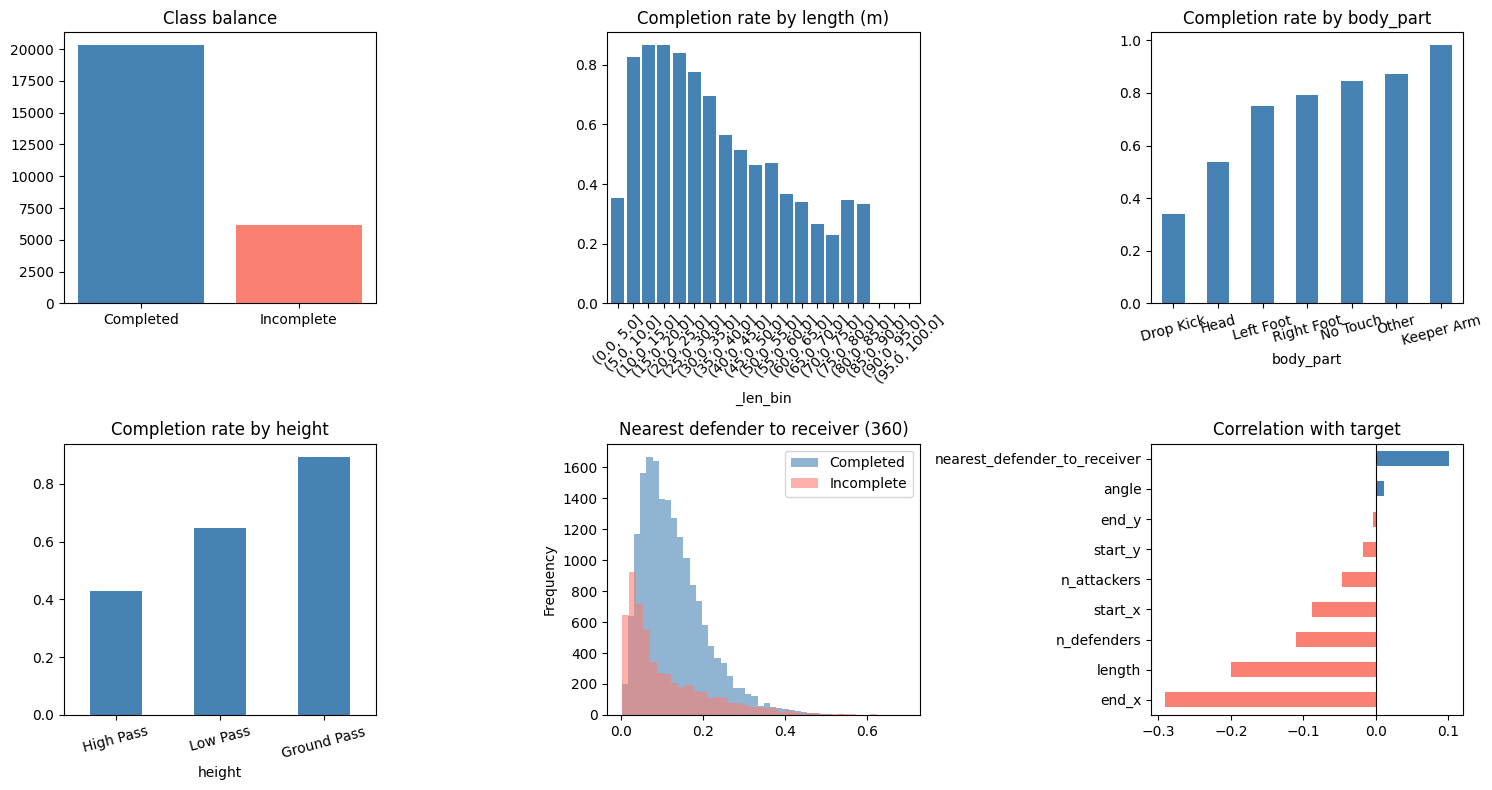

In [18]:
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('passes_360.csv')

# --- Общая сводка ---
print(f"Строк: {len(df)} | Колонок: {df.shape[1]}")
counts = df['completed'].value_counts()
print(f"Completed: {counts[1]} ({counts[1]/len(df)*100:.1f}%)  |  Incomplete: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print()

# --- Пропуски по колонкам ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)
if missing_df.empty:
    print("Пропусков нет")
else:
    print(missing_df.to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Баланс классов
axes[0, 0].bar(['Completed', 'Incomplete'], [counts[1], counts[0]], color=['steelblue', 'salmon'])
axes[0, 0].set_title('Class balance')

# 2. Completion rate по длине паса
bins = np.arange(0, df['length'].max() + 5, 5)
df['_len_bin'] = pd.cut(df['length'], bins=bins)
df.groupby('_len_bin', observed=True)['completed'].mean().plot(
    kind='bar', ax=axes[0, 1], color='steelblue', width=0.85)
axes[0, 1].set_title('Completion rate by length (m)')
axes[0, 1].tick_params(axis='x', rotation=45)
df.drop(columns='_len_bin', inplace=True)

# 3. Completion rate по части тела
df.groupby('body_part')['completed'].mean().sort_values().plot(
    kind='bar', ax=axes[0, 2], color='steelblue')
axes[0, 2].set_title('Completion rate by body_part')
axes[0, 2].tick_params(axis='x', rotation=15)

# 4. Completion rate по высоте паса
df.groupby('height')['completed'].mean().sort_values().plot(
    kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Completion rate by height')
axes[1, 0].tick_params(axis='x', rotation=15)

# 5. Покрытие 360 + влияние nearest_defender
has_360 = df['n_defenders'].notna()
df360 = df[has_360]
df360[df360['completed'] == 1]['nearest_defender_to_receiver'].plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1, 1], label='Completed', color='steelblue')
df360[df360['completed'] == 0]['nearest_defender_to_receiver'].plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1, 1], label='Incomplete', color='salmon')
axes[1, 1].set_title('Nearest defender to receiver (360)')
axes[1, 1].legend()

# 6. Корреляция с таргетом
num_cols = ['length', 'angle', 'start_x', 'start_y', 'end_x', 'end_y',
            'n_defenders', 'n_attackers', 'nearest_defender_to_receiver']
corr = df[num_cols + ['completed']].corr()['completed'].drop('completed').sort_values()
corr.plot(kind='barh', ax=axes[1, 2],
          color=['salmon' if v < 0 else 'steelblue' for v in corr])
axes[1, 2].axvline(0, color='black', linewidth=0.8)
axes[1, 2].set_title('Correlation with target')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from catboost import CatBoostClassifier

df = pd.read_csv('passes_360.csv')

# Оставляем только пасы с 360-данными
before = len(df)
df = df.dropna(subset=['n_defenders', 'n_attackers'])
print(f"Удалено строк без 360-данных: {before - len(df)} | Осталось: {len(df)}")

# nearest_defender_to_receiver и body_part может быть None - заполняем медианой
df['nearest_defender_to_receiver'] = df['nearest_defender_to_receiver'].fillna(
    df['nearest_defender_to_receiver'].median()
)
df['body_part'] = df['body_part'].fillna(df['body_part'].mode()[0])


# Булевы флаги → int
bool_cols = ['under_pressure', 'cross', 'switch', 'through_ball']
df[bool_cols] = df[bool_cols].astype(int)

NUM_FEATURES = [
    'start_x', 'start_y', 'end_x', 'end_y',
    'length', 'angle',
    'under_pressure', 'cross', 'switch', 'through_ball',
    'n_defenders', 'n_attackers', 'nearest_defender_to_receiver',
]
CAT_FEATURES = ['body_part', 'height']
TARGET = 'completed'

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', NUM_FEATURES),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), CAT_FEATURES),
])

X = df[NUM_FEATURES + CAT_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Positive rate: {y.mean():.3f}")

Удалено строк без 360-данных: 3325 | Осталось: 23174
Train: 18539 | Test: 4635 | Positive rate: 0.763


In [20]:
models = {
    'Logistic Regression': Pipeline([('pre', preprocessor),
                                     ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Gradient Boosting':   Pipeline([('pre', preprocessor),
                                     ('clf', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                                        max_depth=4, random_state=42))]),
    # CatBoost умеет работать с категориальными признаками нативно 
    'CatBoost':            CatBoostClassifier(iterations=300, learning_rate=0.05,
                                              depth=4, cat_features=CAT_FEATURES,
                                              random_seed=42, verbose=0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'ROC AUC':     roc_auc_score(y_test, y_prob),
        'Brier score': brier_score_loss(y_test, y_prob),
        'Log loss':    log_loss(y_test, y_prob),
    }
    print(f"{name:25s}  ROC AUC={results[name]['ROC AUC']:.4f}  "
          f"Brier={results[name]['Brier score']:.4f}  "
          f"LogLoss={results[name]['Log loss']:.4f}")

Logistic Regression        ROC AUC=0.8492  Brier=0.1286  LogLoss=0.3960
Gradient Boosting          ROC AUC=0.9071  Brier=0.1025  LogLoss=0.3219
CatBoost                   ROC AUC=0.9042  Brier=0.1033  LogLoss=0.3246


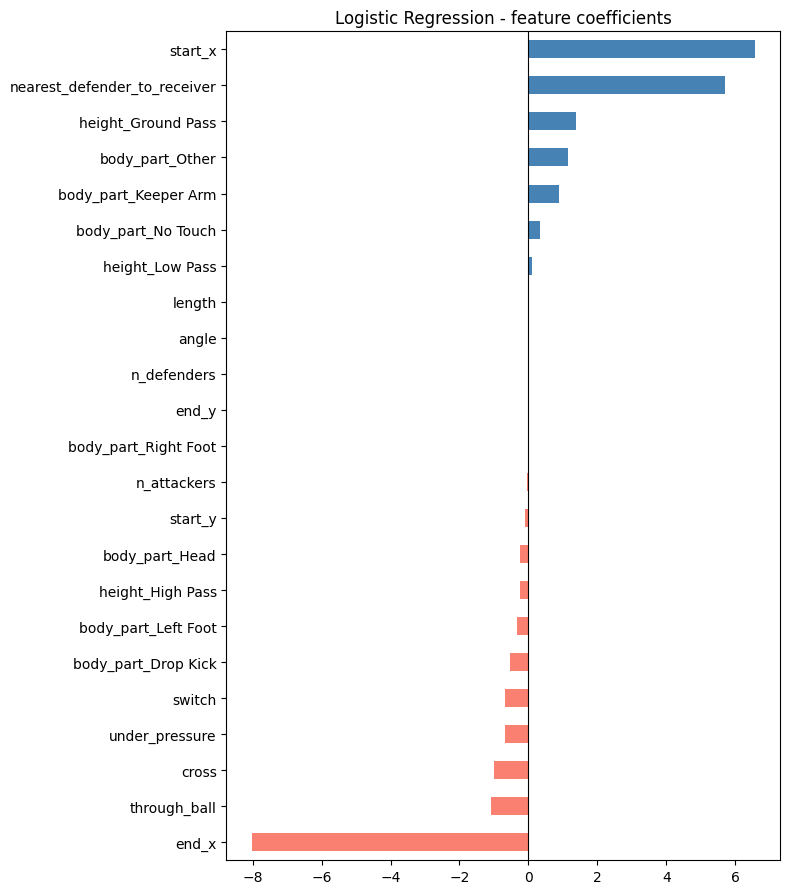

In [24]:
lr = models['Logistic Regression']

feature_names = [n.split('__', 1)[-1] for n in lr.named_steps['pre'].get_feature_names_out()]
coefs = lr.named_steps['clf'].coef_[0]

imp = pd.Series(coefs, index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, len(imp) * 0.35 + 1))
imp.plot(kind="barh", ax=ax, color=["salmon" if v < 0 else "steelblue" for v in imp])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression - feature coefficients")
plt.tight_layout()
plt.show()